In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from PIL import Image
import os
from matplotlib import cm

(0.0, 1424.0, 0.0, 912.0)

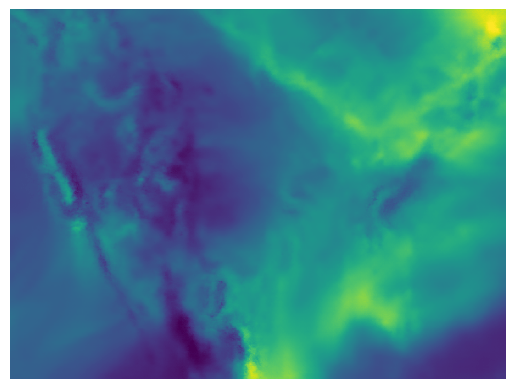

In [2]:
array = np.load('Results/test/us_co2.npy')
plt.pcolormesh(np.flip(array,0), alpha=1, vmin = 0, vmax = 1, cmap = 'viridis')
plt.axis('off')


In [6]:
Image.fromarray(np.uint8(cm.viridis(array)*255)).save('../Recursive_sr/us_co2_1.png')

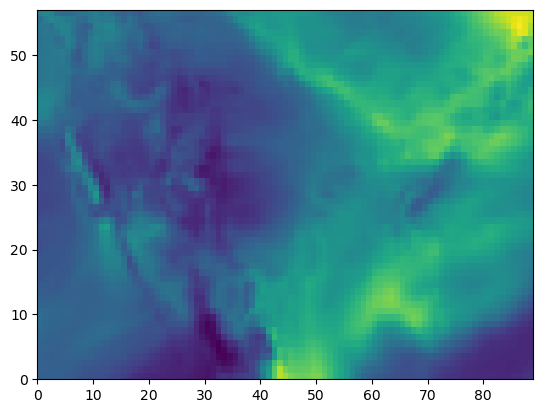

In [7]:
array2 = np.load('Input/test/us_co2.npy')
plt.pcolormesh(np.flip(array2,0), alpha=1, vmin = 0, vmax = 1, cmap = 'viridis')

In [8]:
Image.fromarray(np.uint8(cm.viridis(array2)*255)).save('../Recursive_sr/us_co2_0.png')

In [2]:
def decompose_images(original_image, x_h, c_h, x_w, c_w):
    shape = (x_h, x_w)
    return np.lib.stride_tricks.sliding_window_view(original_image, shape)[::c_h, ::c_w]

In [4]:
array_grid = decompose_images(array, 60, 60, 90, 90)

array_grid_2 = np.flip(array_grid, axis=2)

In [5]:
array_grid.shape

(15, 15, 60, 90)

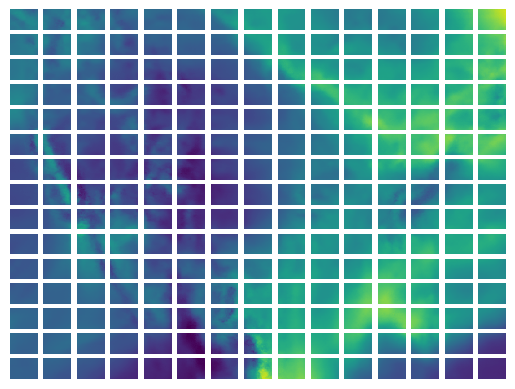

In [6]:
gs = mpl.gridspec.GridSpec(15,15)
for i in range(15):
    for j in range(15):
        ax = plt.subplot(gs[i,j])
        #ax.imshow(test[i,j,...])
        ax.pcolormesh(array_grid_2[i, j, ...], alpha=1, vmin = 0, vmax = 1, cmap = 'viridis')
        ax.axis('off')
        np.save('Input/test_2/us_co2_{}_{}.npy'.format(str(i),str(j)), array_grid_2[i, j, ...])

In [7]:
len([name for name in os.listdir('Input/test_2/')])

225

In [8]:
for i in range(len([name for name in os.listdir('Input/test_2/')])):
    ! python eval.py --upscale_factor 16 --test_dataset test_2 --model weights/MOD_tensorese-hivemindDBPNLL1channel_16_MSE.pth
    ! rm Input/test_2/us_co2_{}_{}.npy'.format(str(i),str(j))

Namespace(upscale_factor=16, testBatchSize=1, gpu_mode=True, self_ensemble=False, chop_forward=False, threads=1, seed=123, gpus=1, input_dir='Input', output='Results/', test_dataset='test_2', model_type='DBPNLL', residual=False, model='weights/MOD_tensorese-hivemindDBPNLL1channel_16_MSE.pth')
===> Loading datasets
===> Building model
Pre-trained SR model is loaded.
===> Processing: us_co2_0_0.npy || Timer: 2.0561 sec.
===> Processing: us_co2_0_1.npy || Timer: 0.0071 sec.
===> Processing: us_co2_0_2.npy || Timer: 0.0071 sec.
===> Processing: us_co2_0_3.npy || Timer: 0.0068 sec.
===> Processing: us_co2_0_4.npy || Timer: 0.0078 sec.
===> Processing: us_co2_0_5.npy || Timer: 0.0070 sec.
===> Processing: us_co2_0_6.npy || Timer: 0.0069 sec.
===> Processing: us_co2_0_7.npy || Timer: 0.0074 sec.
===> Processing: us_co2_0_8.npy || Timer: 0.0081 sec.
===> Processing: us_co2_0_9.npy || Timer: 0.0085 sec.
===> Processing: us_co2_0_10.npy || Timer: 0.0073 sec.
===> Processing: us_co2_0_11.npy || T

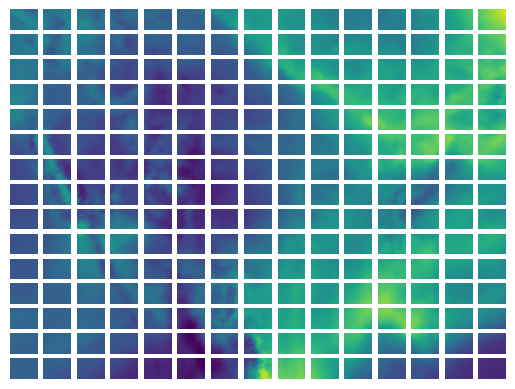

In [2]:
gs = mpl.gridspec.GridSpec(15,15)
for i in range(15):
    for j in range(15):
        ax = plt.subplot(gs[i,j])
        #ax.imshow(test[i,j,...])
        ax.pcolormesh(np.load('Results/test_2/us_co2_{}_{}.npy'.format(i,j)), alpha=1, vmin = 0, vmax = 1, cmap = 'viridis')
        ax.axis('off')

In [9]:
def reconstruct_image(folder, final_shape, sub_image_shape):
    w = final_shape[0]
    h = final_shape[1]
    array = np.zeros((w,h))
    for i in range(15):
        for j in range(15):
            assert np.load(folder + '/us_co2_{}_{}.npy'.format(i,j)).shape == sub_image_shape
            sub_w = sub_image_shape[0]
            sub_h = sub_image_shape[1]
            array[i*sub_w:(i+1)*sub_w,j*sub_h:(j+1)*sub_h] = np.flip(np.load(folder + '/us_co2_{}_{}.npy'.format(i,j)), 0)
    return array

In [10]:
image_sr_2 = reconstruct_image('Results/test_2', (14400, 21600), (960, 1440))

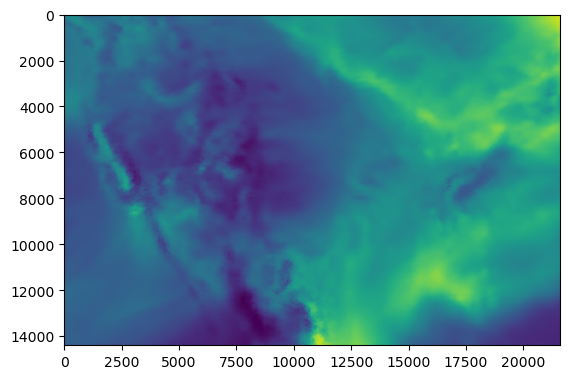

In [11]:
plt.imshow(image_sr_2, alpha=1, vmin = 0, vmax = 1, cmap = 'viridis')

In [12]:
Image.fromarray(np.uint8(cm.viridis(image_sr_2)*255)).save('../Recursive_sr/us_co2_2.png')